In [166]:
import joblib 

In [167]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
targets

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,1,2,0.022036,0.319825,0.363018,0.600159,0.372211
2,2,2,0.044072,0.319035,0.401244,0.560835,0.412939
3,3,2,0.066108,0.317768,0.438220,0.522651,0.452336
4,4,2,0.088145,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...,...
4616,14374,314,0.903482,0.602647,0.400094,0.641878,0.341981
4617,14375,314,0.925518,0.618405,0.398324,0.648210,0.340095
4618,14376,314,0.947554,0.631936,0.397945,0.652486,0.339691
4619,14377,314,0.969590,0.640013,0.399376,0.653355,0.341216


In [170]:
import numpy as np

# Keep features with variance above a threshold
variance_threshold = 0.09
dfs = dfs.loc[:, dfs.var() > variance_threshold]
dfs

,Experiment_ID,BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,
0.00,2,0.999967,1.000000,0.570124,0.000005,0.900879,0.999849
0.05,2,0.999967,1.000000,0.570124,0.000004,0.900879,0.999842
0.10,2,0.999967,1.000000,0.570124,0.000004,0.900879,0.999540
0.15,2,0.999967,1.000000,0.570124,0.000005,0.900879,0.998401
0.20,2,0.999967,1.000000,0.570124,0.000002,0.900879,0.997003
...,...,...,...,...,...,...,...
86.30,314,0.000007,0.997979,0.000004,0.984199,0.094463,0.999849
86.35,314,0.000007,0.998670,0.000004,0.984199,0.094463,0.999849
86.40,314,0.000007,0.999223,0.000004,0.984199,0.094463,0.999849


In [174]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:10,:,:]
Y = np.nan_to_num(y, nan=0.0)[:10,:,1:]
print("Shape:", X.shape, Y.shape)  

Shape: (10, 1743, 6) (10, 47, 5)


In [175]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

dataset = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Seq2Vec LSTM Model
class Seq2VecLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, num_angles):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size * num_angles)
        self.num_angles = num_angles
        self.output_size = output_size

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, (hn, _) = self.lstm(x)       # hn: (num_layers, batch, hidden_size)
        hn = hn[-1]                     # take last layer hidden state: (batch, hidden_size)
        out = self.fc(hn)               # (batch, num_angles*output_size)
        out = out.view(-1, self.num_angles, self.output_size)  # (batch, num_angles, 3)
        return out

input_size = X.shape[2]
hidden_size = 128
num_layers = 2
output_size = Y.shape[2]   # 3
num_angles = Y.shape[1]    # 47

model = Seq2VecLSTM(input_size, hidden_size, num_layers, output_size, num_angles)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    running_loss = 0.0
    for xb, yb in dataloader:
        optimizer.zero_grad()
        y_pred = model(xb)             # (batch, num_angles, 3)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(dataset)
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

# Prediction
model.eval()
with torch.no_grad():
    Y_pred = model(X_tensor).numpy()  # shape: (num_samples, num_angles, 3)

Epoch [5/200], Loss: 0.196955
Epoch [10/200], Loss: 0.193890
Epoch [15/200], Loss: 0.190668
Epoch [20/200], Loss: 0.187147
Epoch [25/200], Loss: 0.183149
Epoch [30/200], Loss: 0.178443
Epoch [35/200], Loss: 0.172699
Epoch [40/200], Loss: 0.165431
Epoch [45/200], Loss: 0.155850
Epoch [50/200], Loss: 0.142607
Epoch [55/200], Loss: 0.123328
Epoch [60/200], Loss: 0.094466
Epoch [65/200], Loss: 0.060568
Epoch [70/200], Loss: 0.054950
Epoch [75/200], Loss: 0.039195
Epoch [80/200], Loss: 0.029466
Epoch [85/200], Loss: 0.023053
Epoch [90/200], Loss: 0.016394
Epoch [95/200], Loss: 0.012570
Epoch [100/200], Loss: 0.009388
Epoch [105/200], Loss: 0.006854
Epoch [110/200], Loss: 0.005242
Epoch [115/200], Loss: 0.003914
Epoch [120/200], Loss: 0.003020
Epoch [125/200], Loss: 0.002367
Epoch [130/200], Loss: 0.001886
Epoch [135/200], Loss: 0.001567
Epoch [140/200], Loss: 0.001334
Epoch [145/200], Loss: 0.001181
Epoch [150/200], Loss: 0.001075
Epoch [155/200], Loss: 0.001004
Epoch [160/200], Loss: 0.000

In [70]:
# Save model 
joblib.dump(model, "lstm.pkl")

['lstm.pkl']

In [ ]:
model = joblib.load("lstm.pkl")

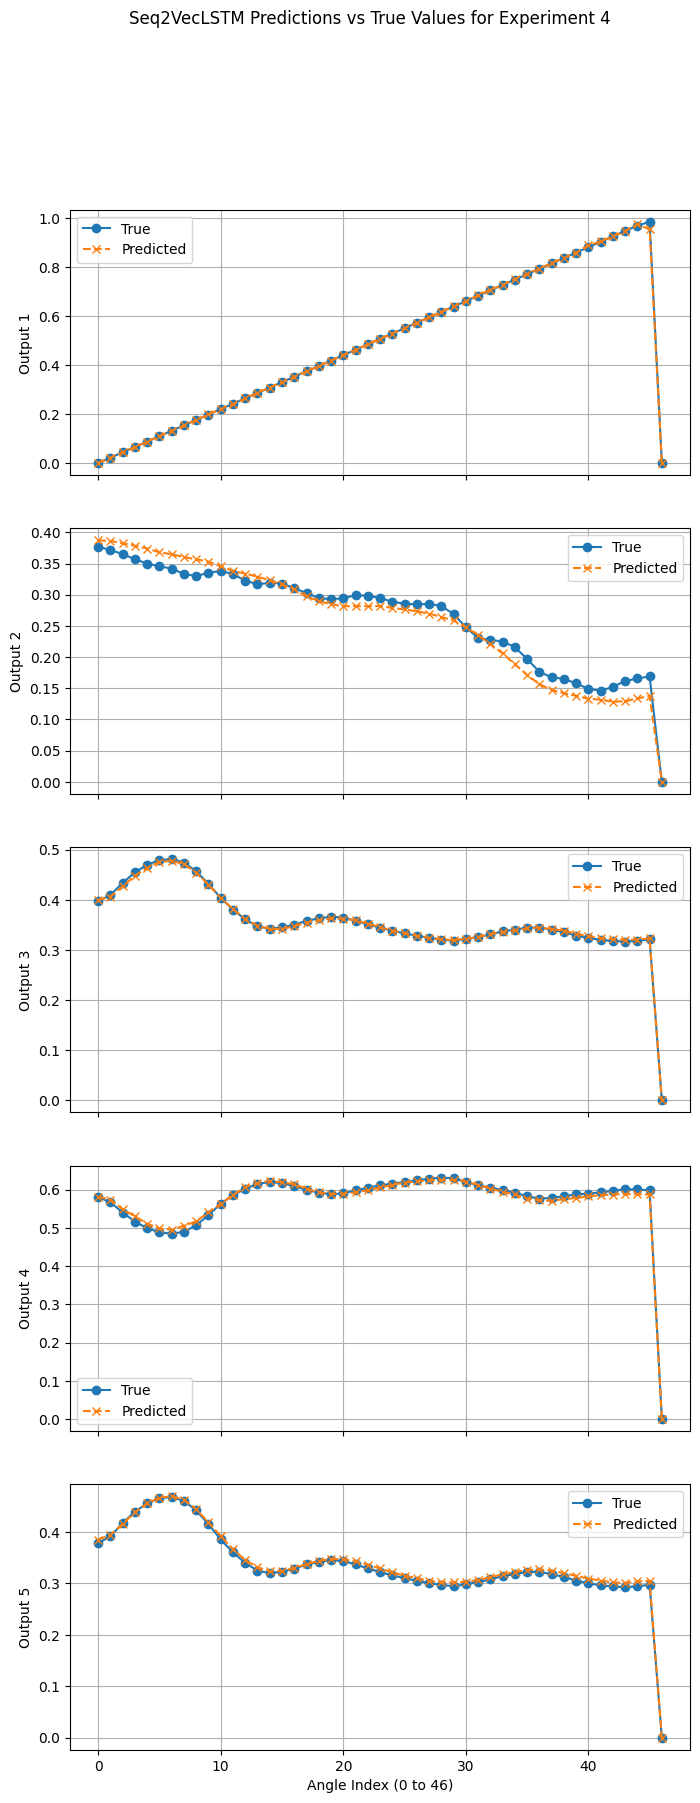

Experiment 4 - MSE: 0.000083, RMSE: 0.009126, MAE: 0.005841


In [176]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import torch

# Make predictions
model.eval()
with torch.no_grad():
    Y_pred = model(X_tensor).detach().cpu().numpy()  # shape: (num_samples, num_angles, num_outputs)

num_outputs = Y_pred.shape[2]

# Select an experiment to visualize
experiment_idx = 4

true_vals = Y_tensor[experiment_idx].cpu().numpy()  # shape: (num_angles, num_outputs)
pred_vals = Y_pred[experiment_idx]                  # shape: (num_angles, num_outputs)

# Plot predictions vs true values
fig, axs = plt.subplots(num_outputs, 1, figsize=(8, 4*num_outputs), sharex=True)
axs = np.atleast_1d(axs)  # ensure axs is array-like even if num_outputs=1

output_names = [f"Output {i+1}" for i in range(num_outputs)]

for i in range(num_outputs):
    axs[i].plot(true_vals[:, i], label="True", marker='o')
    axs[i].plot(pred_vals[:, i], label="Predicted", marker='x', linestyle='--')
    axs[i].set_ylabel(output_names[i])
    axs[i].grid(True)
    axs[i].legend()

axs[-1].set_xlabel("Angle Index (0 to 46)")
plt.suptitle(f"Seq2VecLSTM Predictions vs True Values for Experiment {experiment_idx}")
plt.show()

# Compute evaluation metrics
mse = mean_squared_error(true_vals, pred_vals)
mae = mean_absolute_error(true_vals, pred_vals)
rmse = np.sqrt(mse)

print(f"Experiment {experiment_idx} - MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")


In [177]:
def plot_most_accurate_window_lstm(sample_idx, X, Y, model, num_angles, num_features, patch_size, angle_idx=0):
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    model.eval()  # make sure model is in eval mode
    
    _, seq_len, _ = X.shape
    num_patches = seq_len // patch_size
    
    x_input = X[sample_idx].copy()  # shape: (seq_len, num_features)
    y_true = Y[sample_idx, angle_idx]  # shape: (num_outputs,) or scalar
    y_true = np.array(y_true)

    # ---------- Evaluate error for each patch ----------
    window_errors = []
    for w in range(num_patches):
        x_patch_only = np.zeros_like(x_input)  # mask all other patches
        start = w * patch_size
        end = (w + 1) * patch_size
        x_patch_only[start:end, :] = x_input[start:end, :]  # keep only this patch
        
        # Make prediction
        x_tensor = torch.tensor(x_patch_only[np.newaxis, :, :], dtype=torch.float32)
        with torch.no_grad():
            y_hat = model(x_tensor).cpu().numpy()[0, angle_idx]
        
        if y_true.ndim == 0:
            error = abs(y_true - y_hat)
        else:
            error = np.linalg.norm(y_true - y_hat)
        window_errors.append(error)
    
    window_errors = np.array(window_errors)
    most_accurate_window = np.argmin(window_errors)
    
    # ---------- Plot features + highlight most accurate ----------
    plt.figure(figsize=(12, 6))
    for f in range(num_features):
        plt.plot(x_input[:, f], label=f'Feature {f}')
    
    plt.axvspan(most_accurate_window*patch_size,
                (most_accurate_window+1)*patch_size-1,
                color='green', alpha=0.3, label='Most Accurate Window')
    
    # Overlay error curve for each patch
    error_curve = np.repeat(window_errors, patch_size)
    ax2 = plt.gca().twinx()
    ax2.plot(range(len(error_curve)), error_curve, color='black', linestyle='--',
             linewidth=2, label='Prediction Error per Patch')
    ax2.set_ylabel("Error (L2 norm if vector)")
    
    plt.xlabel("Timestep")
    plt.title(f"Sample {sample_idx}, Angle {angle_idx} - Most Accurate Window & Error Curve")
    plt.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()
    
    # ---------- Predictions for all angles ----------
    x_tensor = torch.tensor(x_input[np.newaxis, :, :], dtype=torch.float32)
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy()[0]  # shape: (num_angles, num_outputs)
    
    # ---------- Plot true vs predicted ----------
    plt.figure(figsize=(12, 6))
    for out_idx in range(Y.shape[2]):
        plt.plot(range(num_angles), Y[sample_idx, :, out_idx], label=f'True Output {out_idx}')
        plt.plot(range(num_angles), preds[:, out_idx], label=f'Predicted Output {out_idx}', linestyle='--', marker='x')
    plt.xlabel("Angle index")
    plt.ylabel("Target value(s)")
    plt.title(f"Predictions for Sample {sample_idx} across all angles")
    plt.legend()
    plt.grid(True)
    plt.show()


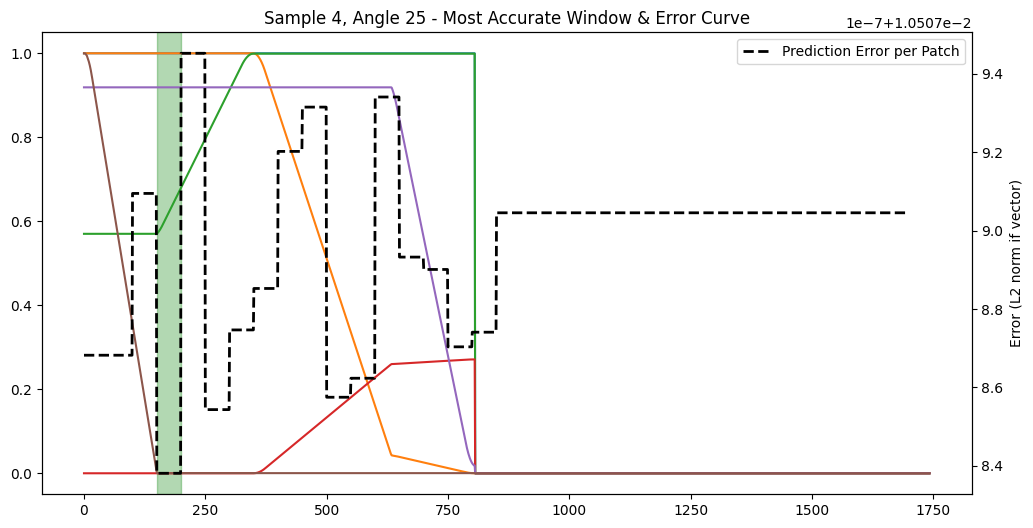

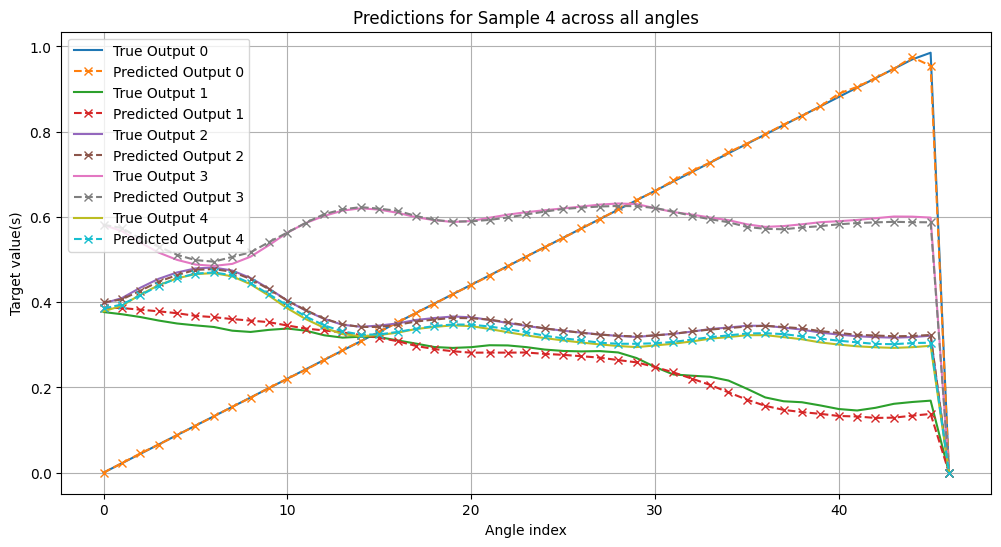

In [188]:
# Parameters
sample_idx = 4
angle_idx = 25
num_angles = Y.shape[1]      # 47
num_features = X.shape[2]    # number of input features per timestep
patch_size = 50               # you can adjust this based on your sequence length

# Call the function
plot_most_accurate_window_lstm(sample_idx, X, Y, model, num_angles, num_features, patch_size, angle_idx)


In [254]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

dataset = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
class Seq2VecLSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, num_angles):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.num_angles = num_angles
        self.output_size = output_size
        
        # Attention layers for each angle
        self.attention_layers = nn.ModuleList([
            nn.Linear(hidden_size, 1) for _ in range(num_angles)
        ])
        
        # Output layers for each angle
        self.fc_layers = nn.ModuleList([
            nn.Linear(hidden_size, output_size) for _ in range(num_angles)
        ])

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)  # lstm_out: (batch, seq_len, hidden_size)
        
        all_attn_scores = []
        angle_outputs = []
        
        for angle_idx in range(self.num_angles):
            # Compute attention scores for this angle
            attn_scores = self.attention_layers[angle_idx](lstm_out).squeeze(-1)  # (batch, seq_len)
            
            # Convert to attention weights
            attn_weights = F.softmax(attn_scores, dim=1)  # (batch, seq_len)
            
            all_attn_scores.append(attn_weights.unsqueeze(1)) 
            
            # Weighted sum of LSTM outputs
            weighted_sum = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)  # (batch, hidden_size)
            
            # Angle-specific output
            angle_out = self.fc_layers[angle_idx](weighted_sum)  # (batch, output_size)
            angle_outputs.append(angle_out.unsqueeze(1))         # (batch, 1, output_size)
        
        out = torch.cat(angle_outputs, dim=1)           # (batch, num_angles, output_size)
        all_attn_scores = torch.cat(all_attn_scores, dim=1)  # (batch, num_angles, seq_len)
        
        return out, all_attn_scores
    
input_size = X.shape[2]
hidden_size = 128
num_layers = 2
output_size = Y.shape[2]   # 3
num_angles = Y.shape[1]    # 47

model = Seq2VecLSTMWithAttention(input_size, hidden_size, num_layers, output_size, num_angles)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    running_loss = 0.0
    for xb, yb in dataloader:
        optimizer.zero_grad()
        y_pred, attn_scores = model(xb)             # (batch, num_angles, 3)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(dataset)
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Epoch [5/200], Loss: 0.200583
Epoch [10/200], Loss: 0.197277
Epoch [15/200], Loss: 0.193735
Epoch [20/200], Loss: 0.189753
Epoch [25/200], Loss: 0.185049
Epoch [30/200], Loss: 0.179228
Epoch [35/200], Loss: 0.171684
Epoch [40/200], Loss: 0.161439
Epoch [45/200], Loss: 0.146815
Epoch [50/200], Loss: 0.125071
Epoch [55/200], Loss: 0.094148
Epoch [60/200], Loss: 0.064817
Epoch [65/200], Loss: 0.055249
Epoch [70/200], Loss: 0.042285
Epoch [75/200], Loss: 0.029724
Epoch [80/200], Loss: 0.022507
Epoch [85/200], Loss: 0.016383
Epoch [90/200], Loss: 0.011673
Epoch [95/200], Loss: 0.008702
Epoch [100/200], Loss: 0.006284
Epoch [105/200], Loss: 0.004520
Epoch [110/200], Loss: 0.003362
Epoch [115/200], Loss: 0.002498
Epoch [120/200], Loss: 0.001916
Epoch [125/200], Loss: 0.001529
Epoch [130/200], Loss: 0.001263
Epoch [135/200], Loss: 0.001100
Epoch [140/200], Loss: 0.000999
Epoch [145/200], Loss: 0.000937
Epoch [150/200], Loss: 0.000901
Epoch [155/200], Loss: 0.000879
Epoch [160/200], Loss: 0.000

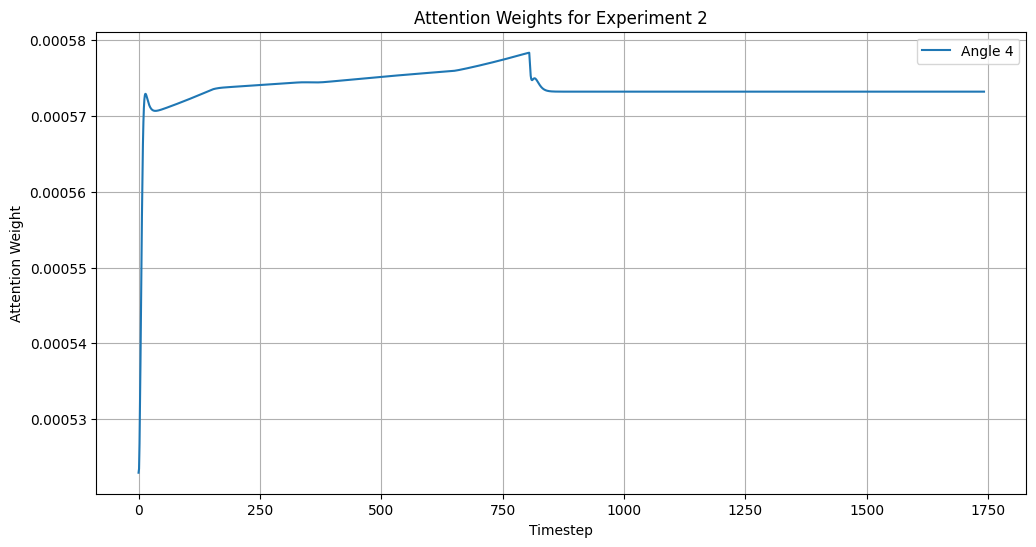

Experiment 2 - MSE: 0.000351, RMSE: 0.018737, MAE: 0.012113


In [261]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import torch

# -----------------------
# Make predictions and get attention weights
# -----------------------
model.eval()
with torch.no_grad():
    Y_pred, attn_weights = model(X_tensor)  # your forward returns (out, all_attn_scores)

# Move to CPU and convert to numpy
Y_pred = Y_pred.detach().cpu().numpy()           # (num_samples, num_angles, num_outputs)
attn_weights = attn_weights.detach().cpu().numpy()  # (num_samples, num_angles, seq_len)

num_outputs = Y_pred.shape[2]
experiment_idx = 2  # select experiment
angle_idx=3

# True and predicted values for this experiment
true_vals = Y_tensor[experiment_idx].cpu().numpy()  # (num_angles, num_outputs)
pred_vals = Y_pred[experiment_idx]                  # (num_angles, num_outputs)

# -----------------------
# Plot predictions vs true values
# -----------------------
# fig, axs = plt.subplots(num_outputs, 1, figsize=(8, 4*num_outputs), sharex=True)
# axs = np.atleast_1d(axs)

# output_names = [f"Output {i+1}" for i in range(num_outputs)]

# for i in range(num_outputs):
#     axs[i].plot(true_vals[:, i], label="True", marker='o')
#     axs[i].plot(pred_vals[:, i], label="Predicted", marker='x', linestyle='--')
#     axs[i].set_ylabel(output_names[i])
#     axs[i].grid(True)
#     axs[i].legend()

# axs[-1].set_xlabel("Angle Index")
# plt.suptitle(f"Seq2VecLSTM Predictions vs True Values for Experiment {experiment_idx}")
# plt.show()

# -----------------------
# Plot attention weights
# -----------------------
attn_exp = attn_weights[experiment_idx]  # shape: (num_angles, seq_len)
if attn_exp.ndim == 1:                   # if batch or angle dimension was squeezed accidentally
    attn_exp = attn_exp[np.newaxis, :]   # make it 2D

num_angles, seq_len = attn_exp.shape

plt.figure(figsize=(12, 6))

plt.plot(range(seq_len), attn_exp[angle_idx], label=f'Angle {angle_idx+1}')
plt.xlabel("Timestep")
plt.ylabel("Attention Weight")
plt.title(f"Attention Weights for Experiment {experiment_idx}")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------
# Compute evaluation metrics
# -----------------------
mse = mean_squared_error(true_vals, pred_vals)
mae = mean_absolute_error(true_vals, pred_vals)
rmse = np.sqrt(mse)

print(f"Experiment {experiment_idx} - MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")
